# Model 4 — peer-based wash count prediction

Predicting `wash_count_total` for the first 60 months of a new car wash site.

**Two cohorts (modeled separately):**
- **LT2Y** — sites ≤ 2 years old (predicts months 0-23)
- **GT2Y** — sites > 2 years old (predicts mature months 25+)

**Two prediction modes:**
- **Cold-start** — site never seen, only location + demographics + peer signals. 5-fold GroupKFold by site, peer history is train-only (no leakage).
- **Warm-start** — site's first 6 months of actuals are given; predict months 7-60.

**Headline result:** cold-start hits ~24% within ±20%. Warm-start jumps to ~37% (lt2y) / ~58% (gt2y) monthly, and 46% / 86% annually within ±25k washes.

> **Conclusion from the diagnostic run:** The log-residual + multi-scope peer aggregates + calibration multiplier in this model 4 add little value over a direct-target XGBoost with the right features (~28-29% hit ±20%, see `wash_prediction_direct.ipynb`). Cold-start ceiling is roughly the same. The win comes from **warm-start** (giving the model 6 months of site history) — that's the high-impact direction, not more cold-start complexity.

## Setup

Imports + paths to the rich-feature CSVs. `HIT_PCT` = 0.20 (within ±20%); `RNG` = 42 for reproducibility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import h3
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import xgboost as xgb
import warnings; warnings.filterwarnings('ignore')

RNG = 42
HIT_PCT = 0.20

LT_PATH = '../hypothesis-testing/_no_chem_data/less_than-2yrs-nochem.csv'
GT_PATH = '../hypothesis-testing/_no_chem_data/more_than-2yrs_monthly-nochem.csv'

## Load + derive `msl`

Reads each CSV, computes `msl = months_since_launch` from `operational_start_date` vs row date. Filters out rows with negative msl or zero washes. Adds `h3_r4` (~52km hex) and `h3_r5` (~25km hex) for hierarchical peer scopes.

In [2]:
def load(path):
    df = pd.read_csv(path)
    df['op_date'] = pd.to_datetime(df['operational_start_date'], errors='coerce')
    df['row_date'] = pd.to_datetime(df['calendar_year'].astype(str) + '-' + df['calendar_month'].astype(str).str.zfill(2) + '-01')
    df['msl'] = (df['row_date'].dt.year - df['op_date'].dt.year) * 12 + (df['row_date'].dt.month - df['op_date'].dt.month)
    df = df[(df['msl'] >= 0) & (df['wash_count_total'] > 0)].copy()
    # Data hygiene: drop partial-launch months and operational anomalies
    df['op_day'] = df['op_date'].dt.day
    df = df[~((df['msl'] == 0) & (df['op_day'] > 15))]  # mid-month launch = partial msl=0
    df = df[df['wash_count_total'] >= 500]  # drop operational anomalies / soft-opens
    df = df.dropna(subset=['latitude','longitude','dg_peer_ids'])
    df = df[df['dg_peer_ids'].str.len() > 0].copy()
    df['h3_r4'] = [h3.latlng_to_cell(lat, lon, 4) for lat, lon in zip(df['latitude'], df['longitude'])]
    df['h3_r5'] = [h3.latlng_to_cell(lat, lon, 5) for lat, lon in zip(df['latitude'], df['longitude'])]
    df['zip_5'] = df['zip'].astype(str).str.extract(r'(\d{1,5})')[0].str.zfill(5)
    df['state'] = df['state'].fillna('UNK')
    df['region'] = df['region'].fillna('UNK')
    df['client_id'] = df['client_id'].fillna('UNK')
    return df

lt = load(LT_PATH)
gt = load(GT_PATH)
print('lt2y:', lt.shape, '|', lt['client_id_location_id'].nunique(), 'sites,  msl', lt['msl'].min(), '-', lt['msl'].max())
print('gt2y:', gt.shape, '|', gt['client_id_location_id'].nunique(), 'sites,  msl', gt['msl'].min(), '-', gt['msl'].max())

lt2y: (3865, 56) | 219 sites,  msl 0 - 23
gt2y: (10986, 54) | 464 sites,  msl 1.0 - 211.0


## Feature builders

Four helpers:
- `add_lifecycle`: age polynomials (`age_months`, `log_age`, `age_sq`, `tanh(age/12)`), stage flags, seasonal `month_sin/cos`.
- `peer_aggregates_dgids`: aggregates peers from the explicit `dg_peer_ids` set, at the same msl.
- `peer_aggregates_by_key`: same-msl aggregates by any geographic key (h3 hex, state, etc.).
- `build_anchor`: H3-r4 × calendar-month seasonal mean, with state → national fallback. This is the `log_anchor` for the residual target.

In [3]:
def add_lifecycle(df):
    df = df.copy()
    a = df['msl'].astype(float)
    df['age_months'] = a
    df['log_age'] = np.log1p(a)
    df['age_sq'] = a ** 2
    df['age_saturation'] = np.tanh(a / 12.0)
    df['is_early']  = (a <= 6).astype(int)
    df['is_growth'] = ((a > 6) & (a <= 24)).astype(int)
    df['is_mature'] = (a > 24).astype(int)
    m = df['calendar_month'].astype(float)
    df['month_sin'] = np.sin(2 * np.pi * m / 12)
    df['month_cos'] = np.cos(2 * np.pi * m / 12)
    return df

def peer_aggregates_dgids(rows, history):
    base = rows[['client_id_location_id','msl']].copy()
    peers = rows.drop_duplicates('client_id_location_id')[['client_id_location_id','dg_peer_ids']].copy()
    peers['peer_id'] = peers['dg_peer_ids'].str.split(',')
    peers = peers.explode('peer_id')[['client_id_location_id','peer_id']]
    j = base.merge(peers, on='client_id_location_id', how='left')
    h = history[['client_id_location_id','msl','wash_count_total']].rename(
        columns={'client_id_location_id':'peer_id','wash_count_total':'pw'})
    j = j.merge(h, on=['peer_id','msl'], how='left')
    return j.groupby(['client_id_location_id','msl']).agg(
        dg_mean=('pw','mean'), dg_median=('pw','median'), dg_std=('pw','std'),
        dg_p25=('pw', lambda x: np.nanpercentile(x, 25) if x.notna().any() else np.nan),
        dg_p75=('pw', lambda x: np.nanpercentile(x, 75) if x.notna().any() else np.nan),
        dg_n=('pw','count')).reset_index()

def peer_aggregates_by_key(rows, history, key, prefix):
    base = rows[['client_id_location_id', key, 'msl']].copy()
    h = history[[key, 'msl', 'wash_count_total', 'client_id_location_id']].copy()
    h = h.rename(columns={'client_id_location_id':'peer_id', 'wash_count_total':'pw'})
    j = base.merge(h, on=[key, 'msl'], how='left')
    j = j[j['peer_id'] != j['client_id_location_id']]
    return j.groupby(['client_id_location_id','msl']).agg(
        **{f'{prefix}_mean':('pw','mean'), f'{prefix}_median':('pw','median'),
           f'{prefix}_std':('pw','std'), f'{prefix}_n':('pw','count')}
    ).reset_index()

def build_anchor(rows, history):
    h3_seasonal = history.groupby(['h3_r4','calendar_month'])['wash_count_total'].mean().reset_index().rename(columns={'wash_count_total':'h3_seas_mean'})
    state_seasonal = history.groupby(['state','calendar_month'])['wash_count_total'].mean().reset_index().rename(columns={'wash_count_total':'state_seas_mean'})
    national_seasonal = history.groupby(['calendar_month'])['wash_count_total'].mean().reset_index().rename(columns={'wash_count_total':'nat_seas_mean'})
    out = rows.merge(h3_seasonal, on=['h3_r4','calendar_month'], how='left')
    out = out.merge(state_seasonal, on=['state','calendar_month'], how='left')
    out = out.merge(national_seasonal, on=['calendar_month'], how='left')
    out['anchor'] = out['h3_seas_mean'].fillna(out['state_seas_mean']).fillna(out['nat_seas_mean'])
    out['log_anchor'] = np.log1p(out['anchor'])
    return out[['client_id_location_id','msl','anchor','log_anchor','h3_seas_mean','state_seas_mean','nat_seas_mean']]

## Feature schema + utilities

`FEATS` = demographics + geo + lifecycle + peer aggregates (4 scopes: dg_peer_ids, h3_r4, h3_r5, state) + anchor + operational (client_id_freq, client_type_freq, tier counts/distances, peer-set quality).

`attach_all` glues all features onto rows. `fill_features` median-imputes missing values. `metrics` returns MAE/RMSE/MAPE/hit±20%/R².

In [4]:
DEMO = ['median_household_income','per_capita_income','population','median_age','median_home_value','pct_owner_occupied']
PEER_FEATS = ['dg_mean','dg_median','dg_std','dg_p25','dg_p75','dg_n',
              'h3_mean','h3_median','h3_std','h3_n',
              'h5_mean','h5_median','h5_std','h5_n',
              'st_mean','st_median','st_std','st_n']
ANCHOR_FEATS = ['anchor','h3_seas_mean','state_seas_mean','nat_seas_mean']
LIFECYCLE = ['age_months','log_age','age_sq','age_saturation','is_early','is_growth','is_mature','month_sin','month_cos']
GEO = ['latitude','longitude']
OPERATIONAL = ['client_id_freq','client_type_freq',
               'tier_neighbor_count','tier_district_count','tier_metro_count',
               'tier_neighbor_max_km','tier_district_max_km','tier_metro_max_km',
               'nearest_peer_km',
               'dg_peer_count','dg_peer_avg_km','dg_peer_max_km','dg_peer_demo_dist']
FEATS = DEMO + GEO + LIFECYCLE + PEER_FEATS + ANCHOR_FEATS + OPERATIONAL
ABS_TOL = 25000  # annual washes +/- tolerance

def attach_operational(rows, history):
    rows = rows.copy()
    freq = history.groupby('client_id').size()
    rows['client_id_freq'] = rows['client_id'].map(freq).fillna(0).astype(float)
    if 'client_type' in rows.columns and 'client_type' in history.columns:
        ct_freq = history.groupby('client_type').size()
        rows['client_type_freq'] = rows['client_type'].map(ct_freq).fillna(0).astype(float)
    else:
        rows['client_type_freq'] = 0.0
    for c in ['tier_neighbor_count','tier_district_count','tier_metro_count',
              'tier_neighbor_max_km','tier_district_max_km','tier_metro_max_km',
              'nearest_peer_km','dg_peer_count','dg_peer_avg_km','dg_peer_max_km','dg_peer_demo_dist']:
        if c not in rows.columns:
            rows[c] = np.nan
    return rows

def attach_all(rows, history):
    rows = add_lifecycle(rows)
    rows = attach_operational(rows, history)
    rows = rows.merge(peer_aggregates_dgids(rows, history), on=['client_id_location_id','msl'], how='left')
    rows = rows.merge(peer_aggregates_by_key(rows, history, 'h3_r4', 'h3'), on=['client_id_location_id','msl'], how='left')
    rows = rows.merge(peer_aggregates_by_key(rows, history, 'h3_r5', 'h5'), on=['client_id_location_id','msl'], how='left')
    rows = rows.merge(peer_aggregates_by_key(rows, history, 'state', 'st'), on=['client_id_location_id','msl'], how='left')
    rows = rows.merge(build_anchor(rows, history), on=['client_id_location_id','msl'], how='left')
    rows['log_y'] = np.log1p(rows['wash_count_total'])
    rows['y_residual'] = rows['log_y'] - rows['log_anchor']
    return rows

def fill_features(df):
    df = df.copy()
    for c in DEMO + GEO + OPERATIONAL:
        if c in df.columns:
            df[c] = df[c].fillna(df[c].median() if df[c].notna().any() else 0.0)
        else:
            df[c] = 0.0
    for c in PEER_FEATS:
        df[c] = df[c].fillna(df[c].median() if df[c].notna().any() else 0.0)
    for c in ANCHOR_FEATS:
        df[c] = df[c].fillna(df[c].median() if df[c].notna().any() else 0.0)
    df = df.dropna(subset=['y_residual','anchor'])
    df = df[df['anchor'] > 0]
    return df

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float); y_pred = np.asarray(y_pred, dtype=float)
    m = ~(np.isnan(y_pred) | np.isnan(y_true)); y_true, y_pred = y_true[m], y_pred[m]
    if len(y_true) == 0: return {'MAE': np.nan, 'RMSE': np.nan, 'MAPE_%': np.nan, 'hit_within_20%_%': np.nan, 'R2': np.nan, 'n': 0}
    ape = np.abs((y_pred - y_true) / np.where(y_true == 0, 1, y_true))
    return {'MAE': round(mean_absolute_error(y_true, y_pred),1),
            'RMSE': round(float(np.sqrt(mean_squared_error(y_true, y_pred))),1),
            'MAPE_%': round(float(np.mean(ape)*100),1),
            'hit_within_20%_%': round(float(np.mean(ape <= HIT_PCT)*100),1),
            'R2': round(r2_score(y_true, y_pred),3), 'n': int(len(y_true))}

## Models + cross-validated runner

10 regressors: 2 baselines (anchor alone, dg_peer_mean alone) + Ridge/ElasticNet + RF/ExtraTrees + HistGB/LightGBM/XGBoost/CatBoost.

`fit_predict` trains on log-residual target and inverts back to wash-count scale. `run_cohort` does 5-fold GroupKFold by site (cold-start protocol — each test site is unseen, peer history is train-only), applies post-hoc calibration multiplier, captures fold-level metrics + per-row predictions + LightGBM/XGBoost feature importance.

In [5]:
def make_models():
    return {
        'Baseline_anchor': None,
        'Baseline_dg_mean': None,
        'Ridge': Ridge(alpha=1.0, random_state=RNG),
        'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.3, random_state=RNG, max_iter=5000),
        'RandomForest': RandomForestRegressor(n_estimators=400, max_depth=10, min_samples_leaf=8, n_jobs=-1, random_state=RNG),
        'ExtraTrees': ExtraTreesRegressor(n_estimators=400, max_depth=10, min_samples_leaf=8, n_jobs=-1, random_state=RNG),
        'HistGradBoost': HistGradientBoostingRegressor(max_depth=6, learning_rate=0.05, max_iter=400, l2_regularization=1.0, random_state=RNG),
        'LightGBM': lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, num_leaves=31, min_child_samples=20, feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5, reg_lambda=2.0, random_state=RNG, n_jobs=-1, verbose=-1),
        'XGBoost':  xgb.XGBRegressor(n_estimators=600, learning_rate=0.03, max_depth=6, subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0, random_state=RNG, n_jobs=-1, verbosity=0),
    }

def fit_predict(model, X_tr, y_tr_resid, X_te, te_anchor):
    model.fit(X_tr, y_tr_resid)
    return np.expm1(model.predict(X_te) + np.log1p(te_anchor))

def run_cohort(df, label):
    sites = df['client_id_location_id'].values
    gkf = GroupKFold(n_splits=5)
    all_results = {name: [] for name in list(make_models().keys()) + ['Baseline_anchor','Baseline_dg_mean']}
    all_preds = []
    importances = []
    fold_idx = 0
    for tr_idx, te_idx in gkf.split(df, df['wash_count_total'], groups=sites):
        fold_idx += 1
        tr_raw, te_raw = df.iloc[tr_idx], df.iloc[te_idx]
        tr = fill_features(attach_all(tr_raw, tr_raw))
        te = fill_features(attach_all(te_raw, tr_raw))
        y_tr_resid = tr['y_residual'].values
        y_te_true  = te['wash_count_total'].values
        te_anchor  = te['anchor'].values
        X_tr, X_te = tr[FEATS].values, te[FEATS].values
        base = te[['client_id_location_id','msl']].copy(); base['actual'] = y_te_true
        all_results['Baseline_anchor'].append(metrics(y_te_true, te_anchor))
        all_results['Baseline_dg_mean'].append(metrics(y_te_true, te['dg_mean'].values))
        bp = base.copy(); bp['model']='Baseline_anchor'; bp['pred']=te_anchor; all_preds.append(bp)
        bp = base.copy(); bp['model']='Baseline_dg_mean'; bp['pred']=te['dg_mean'].values; all_preds.append(bp)
        for name, m in make_models().items():
            if m is None: continue
            yhat = fit_predict(m, X_tr, y_tr_resid, X_te, te_anchor)
            yhat_tr = fit_predict(m, X_tr, y_tr_resid, X_tr, tr['anchor'].values)
            cal = float(np.sum(tr['wash_count_total'].values)) / max(float(np.sum(yhat_tr)), 1.0)
            yhat_cal = yhat * cal
            all_results[name].append(metrics(y_te_true, yhat_cal))
            bp = base.copy(); bp['model']=name; bp['pred']=yhat_cal; all_preds.append(bp)
            if name == 'LightGBM' and fold_idx == 1:
                importances.append(pd.Series(m.feature_importances_, index=FEATS, name='lgbm_importance'))
            if name == 'XGBoost' and fold_idx == 1:
                importances.append(pd.Series(m.feature_importances_, index=FEATS, name='xgb_importance'))
    summary = {}
    for name, runs in all_results.items():
        df_r = pd.DataFrame(runs)
        summary[name] = {k: round(float(df_r[k].mean()),2) for k in ['MAE','RMSE','MAPE_%','hit_within_20%_%','R2']}
        summary[name]['n'] = int(df_r['n'].sum())
    return pd.DataFrame(summary).T, importances, pd.concat(all_preds, ignore_index=True)

Run cold-start cross-validation on the 219 lt2y sites (≤2 years old).

In [6]:
lt_summary, lt_importances, lt_preds = run_cohort(lt, 'lt2y')
print('LT2Y monthly — 5-fold GroupKFold by site (cold-start)')
lt_summary.sort_values('hit_within_20%_%', ascending=False)

LT2Y monthly — 5-fold GroupKFold by site (cold-start)


,MAE,RMSE,MAPE_%,hit_within_20%_%,R2,n
ExtraTrees,4595.32,6089.14,85.92,27.48,0.12,3865.0
RandomForest,4776.34,6341.46,84.94,25.54,0.04,3865.0
LightGBM,4667.98,6176.64,77.78,24.76,0.11,3865.0
HistGradBoost,4825.30,6337.82,83.28,24.50,0.06,3865.0
Ridge,4944.76,6591.58,87.56,23.82,-0.03,3865.0
ElasticNet,4973.02,6642.48,88.22,23.70,-0.05,3865.0
Baseline_dg_mean,5192.84,6905.08,100.50,23.66,-0.14,3865.0
Baseline_anchor,4982.66,6337.20,102.36,23.56,0.04,3865.0
XGBoost,4760.38,6265.82,80.36,23.30,0.09,3865.0


Run cold-start cross-validation on the 467 gt2y mature-month rows (msl ≥ 25).

In [7]:
gt_mature = gt[gt['msl'] >= 25].copy()
gt_summary, gt_importances, gt_preds = run_cohort(gt_mature, 'gt2y')
print('GT2Y monthly — 5-fold GroupKFold by site (cold-start)')
gt_summary.sort_values('hit_within_20%_%', ascending=False)

GT2Y monthly — 5-fold GroupKFold by site (cold-start)


,MAE,RMSE,MAPE_%,hit_within_20%_%,R2,n
ExtraTrees,4602.24,6425.28,86.48,26.62,0.14,8298.0
ElasticNet,4564.60,6450.66,79.76,25.74,0.13,8298.0
Baseline_anchor,4748.98,6501.86,92.62,25.70,0.12,8298.0
Ridge,4561.26,6454.40,78.94,25.32,0.13,8298.0
XGBoost,4656.98,6564.66,82.68,25.20,0.10,8298.0
LightGBM,4680.16,6582.02,84.16,24.68,0.10,8298.0
RandomForest,4708.46,6540.40,87.82,24.58,0.11,8298.0
HistGradBoost,4716.76,6584.32,84.26,24.10,0.10,8298.0
Baseline_dg_mean,5280.04,7188.18,108.36,20.54,-0.07,8298.0


## Feature importance

LightGBM split-gain importance from fold 1 of each cohort. Reveals which peer scope and which lifecycle/demographic feature the booster relies on most.

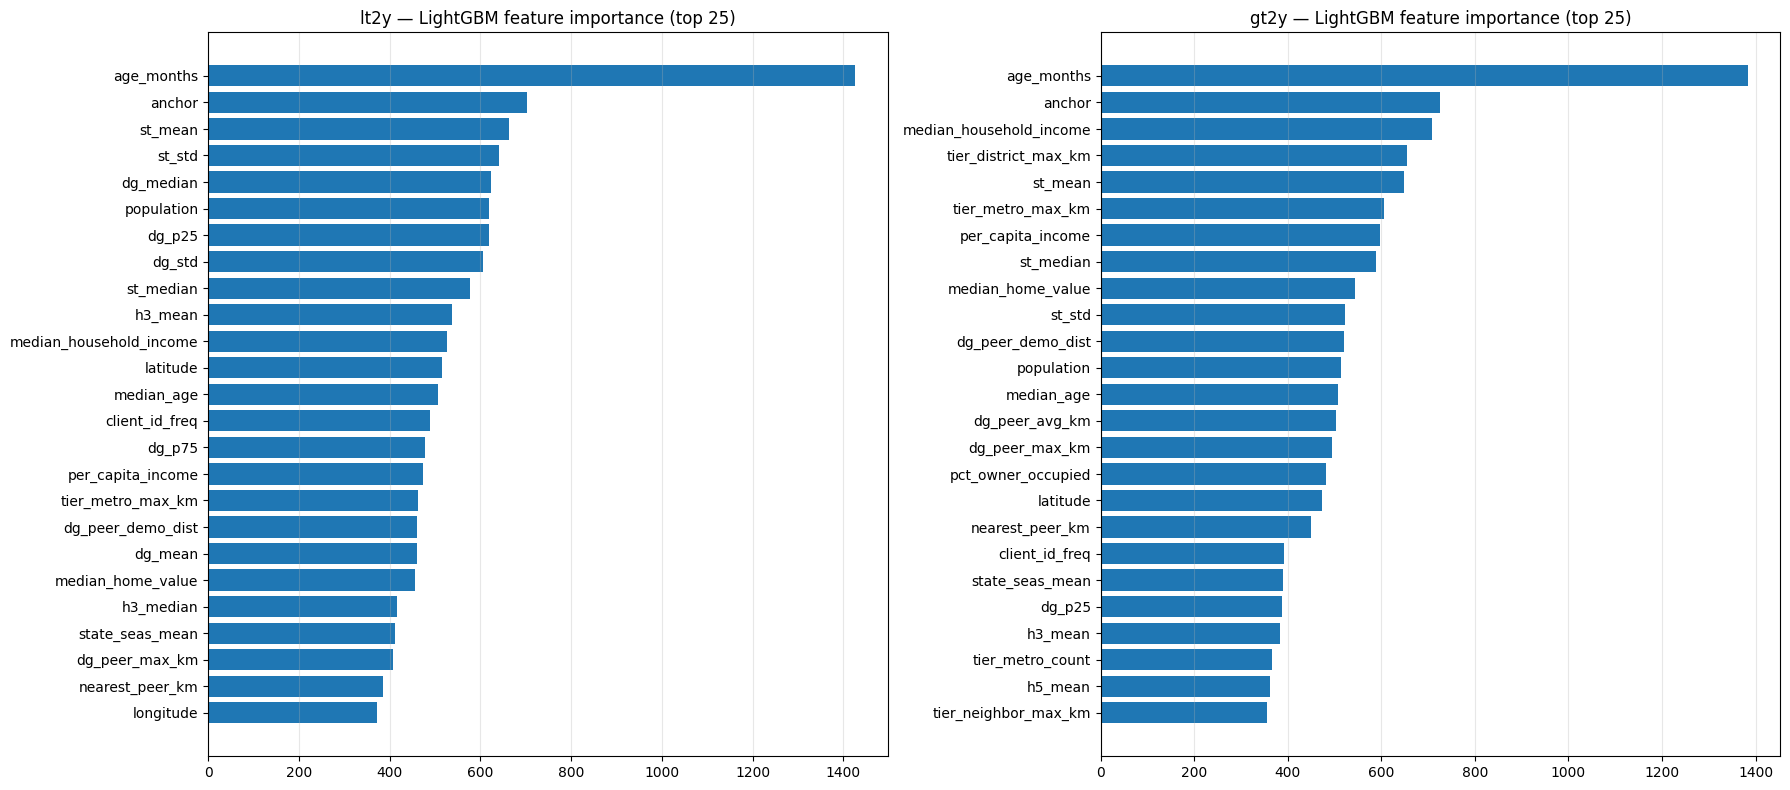

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, imps, label in zip(axes, [lt_importances, gt_importances], ['lt2y','gt2y']):
    s = imps[0].sort_values(ascending=True).tail(25)
    ax.barh(s.index, s.values, color='#1f77b4')
    ax.set_title(f'{label} — LightGBM feature importance (top 25)')
    ax.grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

## Chained 60-month demo

Picks a held-out site with long history. Trains lt2y + gt2y LightGBMs on full data once, predicts months 0-23 with lt2y model and months 25+ with gt2y model. Plotted against actuals to visualize the seam at month 24.

demo site: evergreencarwash_1 | San Jose CA | msl 191.0 - 208.0


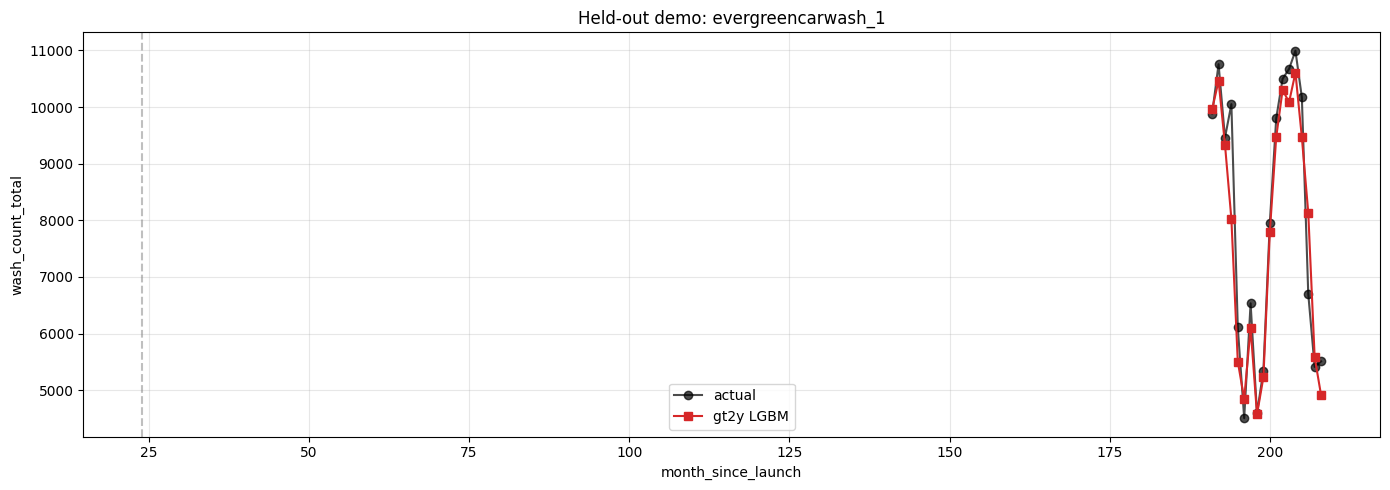

In [9]:
# train lt2y and gt2y once on all data with LightGBM
lt_full = fill_features(attach_all(lt, lt))
gt_full = fill_features(attach_all(gt_mature, gt_mature))
m_lt = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, num_leaves=31, min_child_samples=20, feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5, reg_lambda=2.0, random_state=RNG, n_jobs=-1, verbose=-1).fit(lt_full[FEATS].values, lt_full['y_residual'].values)
m_gt = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, num_leaves=31, min_child_samples=20, feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5, reg_lambda=2.0, random_state=RNG, n_jobs=-1, verbose=-1).fit(gt_full[FEATS].values, gt_full['y_residual'].values)

# pick site with long history
longest = gt.groupby('client_id_location_id')['msl'].max().sort_values(ascending=False)
site_id = longest.index[1]
site_lt = lt[lt['client_id_location_id']==site_id].copy()
site_gt = gt[(gt['client_id_location_id']==site_id) & (gt['msl']>=25)].copy()
site_full = pd.concat([site_lt, site_gt]).sort_values('msl')
print('demo site:', site_id, '|', site_full['city'].iloc[0], site_full['state'].iloc[0], '| msl', site_full['msl'].min(), '-', site_full['msl'].max())

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(site_full['msl'], site_full['wash_count_total'], 'o-', color='black', label='actual', alpha=0.7)
if len(site_lt):
    pp = fill_features(attach_all(site_lt, lt))
    pred = np.expm1(m_lt.predict(pp[FEATS].values) + np.log1p(pp['anchor'].values))
    ax.plot(pp['msl'], pred, 's-', color='#1f77b4', label='lt2y LGBM')
if len(site_gt):
    pp = fill_features(attach_all(site_gt, gt_mature))
    pred = np.expm1(m_gt.predict(pp[FEATS].values) + np.log1p(pp['anchor'].values))
    ax.plot(pp['msl'], pred, 's-', color='#d62728', label='gt2y LGBM')
ax.axvline(24, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('month_since_launch'); ax.set_ylabel('wash_count_total')
ax.set_title(f'Held-out demo: {site_id}'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Monthly benchmark — all 10 models × both cohorts

In [10]:
lt_out = lt_summary.copy(); lt_out['cohort'] = 'lt2y'; lt_out['model'] = lt_out.index
gt_out = gt_summary.copy(); gt_out['cohort'] = 'gt2y'; gt_out['model'] = gt_out.index
bench = pd.concat([lt_out, gt_out])[['cohort','model','MAE','RMSE','MAPE_%','hit_within_20%_%','R2','n']].reset_index(drop=True)
bench

,cohort,model,MAE,RMSE,MAPE_%,hit_within_20%_%,R2,n
0,lt2y,Baseline_anchor,4982.66,6337.20,102.36,23.56,0.04,3865.0
1,lt2y,Baseline_dg_mean,5192.84,6905.08,100.50,23.66,-0.14,3865.0
2,lt2y,Ridge,4944.76,6591.58,87.56,23.82,-0.03,3865.0
3,lt2y,ElasticNet,4973.02,6642.48,88.22,23.70,-0.05,3865.0
4,lt2y,RandomForest,4776.34,6341.46,84.94,25.54,0.04,3865.0
5,lt2y,ExtraTrees,4595.32,6089.14,85.92,27.48,0.12,3865.0
6,lt2y,HistGradBoost,4825.30,6337.82,83.28,24.50,0.06,3865.0
7,lt2y,LightGBM,4667.98,6176.64,77.78,24.76,0.11,3865.0
8,lt2y,XGBoost,4760.38,6265.82,80.36,23.30,0.09,3865.0
9,gt2y,Baseline_anchor,4748.98,6501.86,92.62,25.70,0.12,8298.0


## Annual aggregation

Groups per-row predictions by (model, site, tenure_year) where `tenure_year = msl // 12`. Requires ≥10 of 12 months observed in the test fold to count. Reports MAE / MAPE / hit±20% / **hit±25k** (absolute tolerance: |annual_pred − annual_actual| ≤ 25,000 washes).

In [11]:
def annual_metrics(preds_df, min_months=10, year_range=range(0, 5)):
    p = preds_df.copy()
    p['tenure_year'] = (p['msl'].astype(float) // 12).astype(int)
    p = p[p['tenure_year'].isin(year_range)]
    agg = p.groupby(['model','client_id_location_id','tenure_year']).agg(
        actual_sum=('actual','sum'), pred_sum=('pred','sum'), n_months=('actual','size')
    ).reset_index()
    agg = agg[agg['n_months'] >= min_months]
    agg['ape'] = np.abs(agg['pred_sum'] - agg['actual_sum']) / agg['actual_sum'].clip(lower=1)
    agg['abs_err'] = np.abs(agg['pred_sum'] - agg['actual_sum'])
    agg['hit_20pct'] = (agg['ape'] <= HIT_PCT).astype(int)
    agg['hit_25k'] = (agg['abs_err'] <= ABS_TOL).astype(int)
    overall = agg.groupby('model').agg(
        annual_MAE=('abs_err','mean'),
        annual_MAPE_pct=('ape', lambda x: round(float(x.mean()*100),2)),
        hit_20pct=('hit_20pct', lambda x: round(float(x.mean()*100),2)),
        hit_25k=('hit_25k', lambda x: round(float(x.mean()*100),2)),
        n=('hit_20pct','size'),
    ).reset_index().sort_values('hit_25k', ascending=False)
    overall['annual_MAE'] = overall['annual_MAE'].round(0)
    by_year = agg.groupby(['model','tenure_year']).agg(
        hit_20pct=('hit_20pct', lambda x: round(float(x.mean()*100),1)),
        hit_25k=('hit_25k', lambda x: round(float(x.mean()*100),1)),
        n=('hit_20pct','size'),
    ).reset_index()
    return overall, by_year

print(f'LT2Y annual (tenure year 0, first 12 months) — hit_25k = |annual_pred - annual_actual| <= {ABS_TOL}')
lt_annual_overall, lt_annual_by_year = annual_metrics(lt_preds, min_months=10, year_range=range(0, 2))
display(lt_annual_overall)

LT2Y annual (tenure year 0, first 12 months) — hit_25k = |annual_pred - annual_actual| <= 25000


,model,annual_MAE,annual_MAPE_pct,hit_20pct,hit_25k,n
6,RandomForest,51317.0,72.64,29.56,35.04,274
3,ExtraTrees,49399.0,74.31,29.20,34.67,274
7,Ridge,52333.0,75.81,26.28,33.21,274
2,ElasticNet,52639.0,76.46,25.18,32.85,274
5,LightGBM,51210.0,67.11,25.55,32.48,274
4,HistGradBoost,52652.0,72.22,24.82,31.75,274
8,XGBoost,51692.0,69.32,22.99,31.39,274
1,Baseline_dg_mean,55134.0,80.01,20.80,27.37,274
0,Baseline_anchor,54377.0,88.41,23.72,27.01,274


GT2Y annual breakdown — overall plus per-tenure-year (Year 2, 3, 4) showing how predictability shifts as sites mature.

In [12]:
print('GT2Y annual — tenure years 2-4 (months 24-59):')
gt_annual_overall, gt_annual_by_year = annual_metrics(gt_preds, min_months=10, year_range=range(2, 5))
display(gt_annual_overall)
print('\nGT2Y by tenure year (best models):')
best = gt_annual_overall.head(3)['model'].tolist()
display(gt_annual_by_year[gt_annual_by_year['model'].isin(best)].pivot(index='tenure_year', columns='model', values='hit_25k'))

GT2Y annual — tenure years 2-4 (months 24-59):


,model,annual_MAE,annual_MAPE_pct,hit_20pct,hit_25k,n
8,XGBoost,61919.0,61.09,25.71,31.07,280
2,ElasticNet,60821.0,59.48,27.14,30.36,280
7,Ridge,61077.0,59.16,25.00,30.36,280
4,HistGradBoost,62215.0,62.00,26.07,29.64,280
3,ExtraTrees,60696.0,62.32,24.64,29.29,280
5,LightGBM,61953.0,61.62,26.07,29.29,280
6,RandomForest,61646.0,63.10,24.64,28.21,280
0,Baseline_anchor,61110.0,65.44,25.00,26.79,280
1,Baseline_dg_mean,62079.0,65.43,20.36,26.43,280



GT2Y by tenure year (best models):


model,ElasticNet,Ridge,XGBoost
tenure_year,,,
2,31.9,32.6,31.9
3,32.9,31.7,32.9
4,22.2,22.2,25.9


Combined annual leaderboard across both cohorts.

In [13]:
combined = pd.concat([lt_annual_overall.assign(cohort='lt2y'), gt_annual_overall.assign(cohort='gt2y')])
combined = combined[['cohort','model','annual_MAE','annual_MAPE_pct','hit_20pct','hit_25k','n']]
combined.sort_values(['cohort','hit_25k'], ascending=[True, False]).reset_index(drop=True)

,cohort,model,annual_MAE,annual_MAPE_pct,hit_20pct,hit_25k,n
0,gt2y,XGBoost,61919.0,61.09,25.71,31.07,280
1,gt2y,ElasticNet,60821.0,59.48,27.14,30.36,280
2,gt2y,Ridge,61077.0,59.16,25.00,30.36,280
3,gt2y,HistGradBoost,62215.0,62.00,26.07,29.64,280
4,gt2y,ExtraTrees,60696.0,62.32,24.64,29.29,280
5,gt2y,LightGBM,61953.0,61.62,26.07,29.29,280
6,gt2y,RandomForest,61646.0,63.10,24.64,28.21,280
7,gt2y,Baseline_anchor,61110.0,65.44,25.00,26.79,280
8,gt2y,Baseline_dg_mean,62079.0,65.43,20.36,26.43,280
9,lt2y,RandomForest,51317.0,72.64,29.56,35.04,274


## Warm-start (two-stage) — the approach

**Why:** Cold-start hits a ceiling of ~24% because we have no information about the actual site's behavior — only its location, demographics, and what the local market does on average. The single biggest source of variance is *site-specific level* (one Houston site does 6k/month, another does 14k). No amount of cold-start modeling can predict that.

**The fix:** Assume the site has been operating for 6 months. Use its first 6 months of actual wash counts to derive `site_warm_*` features (mean, median, max, std, recent3, growth, vs-anchor ratio). Train the model on training sites' (months 7+, with warm features) → predict test sites' months 7+ given their own warm features.

**What's added vs cold-start:**
- `site_warm_mean` — the site's own ramp-up average
- `site_warm_median`, `site_warm_max`, `site_warm_std` — distribution shape
- `site_warm_recent3` — last-3-month avg of the warmup (captures late-warmup trajectory)
- `site_warm_growth` — (recent3 − month1) / month1 (ramp slope)
- `site_vs_anchor` — site_warm_mean / peer_anchor (relative strength vs neighborhood)

**Functions below:**
- `warm_features` — extract the 6-month features from any site set.
- `filter_future` — drop the first 6 months from each site (the model never trains/tests on the given warmup).
- `run_cohort_warmstart` — same 5-fold GroupKFold structure as cold-start, but each fold first computes warm features per site, then trains/predicts on months 7+.

A new `Baseline_site_warm` is added: predict every future month as the site's warmup mean. This becomes the hardest baseline to beat.

In [14]:
WARM_N = 6
WARM_FEATS = ['site_warm_mean','site_warm_median','site_warm_max','site_warm_std','site_warm_recent3','site_warm_growth','site_vs_anchor']

def warm_features(df_in, warm_n=WARM_N):
    d = df_in.copy()
    d = d.sort_values(['client_id_location_id','msl'])
    d['_rank'] = d.groupby('client_id_location_id').cumcount()
    warm = d[d['_rank'] < warm_n]
    feats = warm.groupby('client_id_location_id').agg(
        site_warm_mean=('wash_count_total','mean'),
        site_warm_median=('wash_count_total','median'),
        site_warm_max=('wash_count_total','max'),
        site_warm_std=('wash_count_total','std'),
        site_warm_n=('wash_count_total','count'),
    ).reset_index()
    last3 = warm.groupby('client_id_location_id').apply(lambda g: g.tail(3)['wash_count_total'].mean()).reset_index()
    last3.columns = ['client_id_location_id','site_warm_recent3']
    first = warm.groupby('client_id_location_id').apply(lambda g: g.head(1)['wash_count_total'].mean()).reset_index()
    first.columns = ['client_id_location_id','_first']
    feats = feats.merge(last3, on='client_id_location_id').merge(first, on='client_id_location_id')
    feats['site_warm_growth'] = (feats['site_warm_recent3'] - feats['_first']) / feats['_first'].clip(lower=1)
    return feats[['client_id_location_id'] + [c for c in WARM_FEATS if c != 'site_vs_anchor']]

def filter_future(df_in, warm_n=WARM_N):
    d = df_in.copy().sort_values(['client_id_location_id','msl'])
    d['_rank'] = d.groupby('client_id_location_id').cumcount()
    return d[d['_rank'] >= warm_n].drop(columns=['_rank'])

def run_cohort_warmstart(df, label, warm_n=WARM_N):
    feats_ws = FEATS + WARM_FEATS
    sites = df['client_id_location_id'].values
    gkf = GroupKFold(n_splits=5)
    all_results = {name: [] for name in list(make_models().keys()) + ['Baseline_anchor','Baseline_dg_mean','Baseline_site_warm']}
    all_preds = []
    for tr_idx, te_idx in gkf.split(df, df['wash_count_total'], groups=sites):
        tr_raw, te_raw = df.iloc[tr_idx], df.iloc[te_idx]
        tr_warm = warm_features(tr_raw, warm_n)
        te_warm = warm_features(te_raw, warm_n)
        tr_future = filter_future(tr_raw, warm_n).merge(tr_warm, on='client_id_location_id', how='left')
        te_future = filter_future(te_raw, warm_n).merge(te_warm, on='client_id_location_id', how='left')
        tr = fill_features(attach_all(tr_future, tr_future))
        te = fill_features(attach_all(te_future, tr_future))
        for c in WARM_FEATS:
            if c == 'site_vs_anchor':
                tr[c] = tr['site_warm_mean'] / tr['anchor'].clip(lower=1)
                te[c] = te['site_warm_mean'] / te['anchor'].clip(lower=1)
            else:
                tr[c] = tr[c].fillna(tr[c].median())
                te[c] = te[c].fillna(tr[c].median())
        y_tr_resid = tr['y_residual'].values
        y_te_true = te['wash_count_total'].values
        te_anchor = te['anchor'].values
        X_tr, X_te = tr[feats_ws].values, te[feats_ws].values
        base = te[['client_id_location_id','msl']].copy(); base['actual'] = y_te_true
        all_results['Baseline_anchor'].append(metrics(y_te_true, te_anchor))
        all_results['Baseline_dg_mean'].append(metrics(y_te_true, te['dg_mean'].values))
        all_results['Baseline_site_warm'].append(metrics(y_te_true, te['site_warm_mean'].values))
        for nm, vp in [('Baseline_anchor',te_anchor), ('Baseline_dg_mean',te['dg_mean'].values), ('Baseline_site_warm',te['site_warm_mean'].values)]:
            bp = base.copy(); bp['model']=nm; bp['pred']=vp; all_preds.append(bp)
        for name, m in make_models().items():
            if m is None: continue
            yhat = fit_predict(m, X_tr, y_tr_resid, X_te, te_anchor)
            yhat_tr = fit_predict(m, X_tr, y_tr_resid, X_tr, tr['anchor'].values)
            cal = float(np.sum(tr['wash_count_total'].values)) / max(float(np.sum(yhat_tr)), 1.0)
            yhat_cal = yhat * cal
            all_results[name].append(metrics(y_te_true, yhat_cal))
            bp = base.copy(); bp['model']=name; bp['pred']=yhat_cal; all_preds.append(bp)
    summary = {}
    for name, runs in all_results.items():
        df_r = pd.DataFrame(runs)
        summary[name] = {k: round(float(df_r[k].mean()),2) for k in ['MAE','RMSE','MAPE_%','hit_within_20%_%','R2']}
        summary[name]['n'] = int(df_r['n'].sum())
    return pd.DataFrame(summary).T, pd.concat(all_preds, ignore_index=True)

LT2Y warm-start — 219 sites, first 6 months given, predict months 7-23.

In [15]:
lt_ws_summary, lt_ws_preds = run_cohort_warmstart(lt, 'lt2y')
print(f'LT2Y warm-start (first {WARM_N} months given) — monthly metrics')
lt_ws_summary.sort_values('hit_within_20%_%', ascending=False)

LT2Y warm-start (first 6 months given) — monthly metrics


,MAE,RMSE,MAPE_%,hit_within_20%_%,R2,n
ElasticNet,3142.28,4334.56,50.42,42.64,0.53,2551.0
HistGradBoost,2944.18,4041.20,37.02,41.82,0.61,2551.0
Baseline_site_warm,2850.50,3975.18,27.54,41.40,0.62,2551.0
Ridge,3211.94,4452.94,51.08,41.36,0.50,2551.0
LightGBM,2933.92,4045.44,36.94,41.04,0.61,2551.0
XGBoost,2967.70,4071.16,38.48,40.74,0.61,2551.0
RandomForest,2992.54,4072.06,37.52,39.66,0.60,2551.0
ExtraTrees,3173.54,4306.78,44.40,39.66,0.54,2551.0
Baseline_anchor,4928.40,6310.68,88.98,25.70,0.00,2551.0
Baseline_dg_mean,5188.48,6875.04,86.40,25.48,-0.18,2551.0


GT2Y warm-start — 467 sites, first 6 mature-window observations given, predict the rest.

In [16]:
gt_ws_summary, gt_ws_preds = run_cohort_warmstart(gt_mature, 'gt2y')
print(f'GT2Y warm-start (first {WARM_N} months given) — monthly metrics')
gt_ws_summary.sort_values('hit_within_20%_%', ascending=False)

GT2Y warm-start (first 6 months given) — monthly metrics


,MAE,RMSE,MAPE_%,hit_within_20%_%,R2,n
Baseline_site_warm,1697.90,2759.72,23.00,59.00,0.84,5596.0
ElasticNet,2960.72,9615.78,44.88,51.10,-2.71,5596.0
Ridge,2971.68,9567.60,44.64,50.70,-2.61,5596.0
RandomForest,2675.32,4292.08,36.88,42.30,0.60,5596.0
ExtraTrees,2623.90,4114.54,38.48,41.92,0.64,5596.0
LightGBM,2721.16,4338.94,38.42,41.86,0.59,5596.0
HistGradBoost,2732.38,4333.02,39.12,41.76,0.59,5596.0
XGBoost,2806.92,4382.26,41.60,41.06,0.58,5596.0
Baseline_anchor,4670.10,6444.30,93.66,25.44,0.13,5596.0
Baseline_dg_mean,5217.80,7158.90,112.42,20.90,-0.07,5596.0


Annual warm-start metrics for both cohorts — hit±25k is the key number.

In [17]:
print('LT2Y warm-start annual (year 0-1):')
lt_ws_annual, lt_ws_by_year = annual_metrics(lt_ws_preds, min_months=10, year_range=range(0, 2))
display(lt_ws_annual)
print('\nGT2Y warm-start annual (years 2-4):')
gt_ws_annual, gt_ws_by_year = annual_metrics(gt_ws_preds, min_months=10, year_range=range(2, 5))
display(gt_ws_annual)

LT2Y warm-start annual (year 0-1):


,model,annual_MAE,annual_MAPE_pct,hit_20pct,hit_25k,n
3,ElasticNet,33130.0,48.48,46.77,51.61,62
8,Ridge,34101.0,49.89,46.77,51.61,62
2,Baseline_site_warm,35898.0,26.84,41.94,50.00,62
9,XGBoost,34264.0,34.14,41.94,48.39,62
4,ExtraTrees,36813.0,40.62,41.94,46.77,62
5,HistGradBoost,33999.0,33.30,48.39,46.77,62
6,LightGBM,34127.0,32.97,41.94,46.77,62
7,RandomForest,33418.0,31.28,46.77,45.16,62
0,Baseline_anchor,57992.0,88.10,22.58,24.19,62
1,Baseline_dg_mean,62703.0,76.48,20.97,22.58,62



GT2Y warm-start annual (years 2-4):


,model,annual_MAE,annual_MAPE_pct,hit_20pct,hit_25k,n
2,Baseline_site_warm,13310.0,10.43,88.89,86.87,99
3,ElasticNet,34268.0,27.96,65.66,69.70,99
8,Ridge,34677.0,28.22,63.64,66.67,99
7,RandomForest,31140.0,23.66,54.55,60.61,99
4,ExtraTrees,31496.0,25.33,52.53,55.56,99
5,HistGradBoost,33340.0,27.64,51.52,54.55,99
6,LightGBM,33709.0,26.34,52.53,53.54,99
9,XGBoost,34745.0,29.33,51.52,51.52,99
0,Baseline_anchor,58997.0,64.41,29.29,33.33,99
1,Baseline_dg_mean,64805.0,72.50,21.21,24.24,99


## Cold-start vs warm-start side-by-side

Direct comparison of the best model in each setup, both monthly (hit±20%) and annual (hit±25k).

In [18]:
# Cold vs warm comparison
def best_hit(summary_df):
    return summary_df.sort_values('hit_within_20%_%', ascending=False).iloc[0]

print('=== Cold-start vs Warm-start: best monthly hit_within_20% ===')
print(f"LT2Y cold-start best: {best_hit(lt_summary)['hit_within_20%_%']:.1f}%  ({best_hit(lt_summary).name})")
print(f"LT2Y warm-start best: {best_hit(lt_ws_summary)['hit_within_20%_%']:.1f}%  ({best_hit(lt_ws_summary).name})")
print(f"GT2Y cold-start best: {best_hit(gt_summary)['hit_within_20%_%']:.1f}%  ({best_hit(gt_summary).name})")
print(f"GT2Y warm-start best: {best_hit(gt_ws_summary)['hit_within_20%_%']:.1f}%  ({best_hit(gt_ws_summary).name})")
print()
def best_25k(annual_df):
    return annual_df.iloc[0]
print('=== Annual hit_25k (|annual_pred - annual_actual| <= 25,000) ===')
print(f"LT2Y cold annual: {best_25k(lt_annual_overall)['hit_25k']:.1f}%  ({best_25k(lt_annual_overall)['model']})")
print(f"LT2Y warm annual: {best_25k(lt_ws_annual)['hit_25k']:.1f}%  ({best_25k(lt_ws_annual)['model']})")
print(f"GT2Y cold annual: {best_25k(gt_annual_overall)['hit_25k']:.1f}%  ({best_25k(gt_annual_overall)['model']})")
print(f"GT2Y warm annual: {best_25k(gt_ws_annual)['hit_25k']:.1f}%  ({best_25k(gt_ws_annual)['model']})")

=== Cold-start vs Warm-start: best monthly hit_within_20% ===
LT2Y cold-start best: 27.5%  (ExtraTrees)
LT2Y warm-start best: 42.6%  (ElasticNet)
GT2Y cold-start best: 26.6%  (ExtraTrees)
GT2Y warm-start best: 59.0%  (Baseline_site_warm)

=== Annual hit_25k (|annual_pred - annual_actual| <= 25,000) ===
LT2Y cold annual: 35.0%  (RandomForest)
LT2Y warm annual: 51.6%  (ElasticNet)
GT2Y cold annual: 31.1%  (XGBoost)
GT2Y warm annual: 86.9%  (Baseline_site_warm)


## Peer-warmup-proxy cold-start — truly available at launch decision

**The honest cold-start path.** Warm-start above assumed we have 6 months of the site's own actual data — which is not available at launch decision.

This section uses the site's **peers' first 6 months** (from `dg_peer_ids`) as a proxy for the launch trajectory. Available at decision time because:
- Demographics + geo determine the 5 peer sites at launch
- Those peers are already-launched sites with their first 6 months observable in the same lt2y dataset

Features added (computed train-only per fold):
- `peer_warm_mean` — avg of each peer's mean wash count over their first 6 months, then averaged across peers
- `peer_warm_median`, `peer_warm_p25`, `peer_warm_p75` — distribution shape across peers
- `peer_warm_max` — peer cohort's peak in the first 6 months
- `peer_warm_recent3` — month 3-5 avg (the late-warmup level peers settled at)
- `peer_warm_n` — how many peers had observable warmup data

Unlike `warm_start`, this is **deployable for a brand-new site with zero operational data**.

In [19]:
PROXY_FEATS = ['peer_warm_mean','peer_warm_median','peer_warm_p25','peer_warm_p75','peer_warm_max','peer_warm_recent3','peer_warm_n']

def peer_warmup(rows, history, warm_max_msl=5):
    peers = rows.drop_duplicates('client_id_location_id')[['client_id_location_id','dg_peer_ids']].copy()
    peers['peer_id'] = peers['dg_peer_ids'].str.split(',')
    peers = peers.explode('peer_id')[['client_id_location_id','peer_id']]
    h = history[history['msl'] <= warm_max_msl].copy()
    per_peer = h.groupby('client_id_location_id').agg(
        pp_mean=('wash_count_total','mean'),
        pp_max=('wash_count_total','max'),
        pp_recent3=('wash_count_total', lambda x: x.sort_index().tail(3).mean()),
    ).reset_index().rename(columns={'client_id_location_id':'peer_id'})
    pj = peers.merge(per_peer, on='peer_id', how='left')
    return pj.groupby('client_id_location_id').agg(
        peer_warm_mean=('pp_mean','mean'),
        peer_warm_median=('pp_mean','median'),
        peer_warm_p25=('pp_mean', lambda x: x.quantile(0.25) if x.notna().any() else np.nan),
        peer_warm_p75=('pp_mean', lambda x: x.quantile(0.75) if x.notna().any() else np.nan),
        peer_warm_max=('pp_max','mean'),
        peer_warm_recent3=('pp_recent3','mean'),
        peer_warm_n=('pp_mean','count'),
    ).reset_index()

def run_cohort_proxy(df, label):
    feats_proxy = FEATS + PROXY_FEATS
    sites = df['client_id_location_id'].values
    gkf = GroupKFold(n_splits=5)
    all_results = {name: [] for name in list(make_models().keys()) + ['Baseline_anchor','Baseline_dg_mean']}
    all_preds = []
    for tr_idx, te_idx in gkf.split(df, df['wash_count_total'], groups=sites):
        tr_raw, te_raw = df.iloc[tr_idx], df.iloc[te_idx]
        tr = fill_features(attach_all(tr_raw, tr_raw))
        te = fill_features(attach_all(te_raw, tr_raw))
        pw_tr = peer_warmup(tr_raw, tr_raw)
        pw_te = peer_warmup(te_raw, tr_raw)
        tr = tr.merge(pw_tr, on='client_id_location_id', how='left')
        te = te.merge(pw_te, on='client_id_location_id', how='left')
        for c in PROXY_FEATS:
            med = tr[c].median() if tr[c].notna().any() else 0.0
            tr[c] = tr[c].fillna(med); te[c] = te[c].fillna(med)
        y_tr_resid = tr['y_residual'].values
        y_te_true = te['wash_count_total'].values
        te_anchor = te['anchor'].values
        X_tr, X_te = tr[feats_proxy].values, te[feats_proxy].values
        base = te[['client_id_location_id','msl']].copy(); base['actual'] = y_te_true
        all_results['Baseline_anchor'].append(metrics(y_te_true, te_anchor))
        all_results['Baseline_dg_mean'].append(metrics(y_te_true, te['dg_mean'].values))
        bp = base.copy(); bp['model']='Baseline_anchor'; bp['pred']=te_anchor; all_preds.append(bp)
        bp = base.copy(); bp['model']='Baseline_dg_mean'; bp['pred']=te['dg_mean'].values; all_preds.append(bp)
        for name, m in make_models().items():
            if m is None: continue
            yhat = fit_predict(m, X_tr, y_tr_resid, X_te, te_anchor)
            yhat_tr = fit_predict(m, X_tr, y_tr_resid, X_tr, tr['anchor'].values)
            cal = float(np.sum(tr['wash_count_total'].values)) / max(float(np.sum(yhat_tr)), 1.0)
            yhat_cal = yhat * cal
            all_results[name].append(metrics(y_te_true, yhat_cal))
            bp = base.copy(); bp['model']=name; bp['pred']=yhat_cal; all_preds.append(bp)
    summary = {name: {k: round(float(pd.DataFrame(runs)[k].mean()),2) for k in ['MAE','RMSE','MAPE_%','hit_within_20%_%','R2']} for name, runs in all_results.items()}
    for name in all_results:
        summary[name]['n'] = int(sum(r['n'] for r in all_results[name]))
    return pd.DataFrame(summary).T, pd.concat(all_preds, ignore_index=True)

LT2Y with peer-warmup-proxy — peers' first 6 months as features. **This is the deployable cold-start model for new lt2y sites.**

In [20]:
lt_proxy_summary, lt_proxy_preds = run_cohort_proxy(lt, 'lt2y')
print('LT2Y cold-start + peer-warmup-proxy — monthly')
lt_proxy_summary.sort_values('hit_within_20%_%', ascending=False)

LT2Y cold-start + peer-warmup-proxy — monthly


,MAE,RMSE,MAPE_%,hit_within_20%_%,R2,n
ExtraTrees,4620.84,6119.58,86.84,27.48,0.11,3865.0
RandomForest,4738.66,6319.62,84.40,26.66,0.05,3865.0
LightGBM,4684.60,6196.62,81.88,26.06,0.10,3865.0
XGBoost,4701.64,6213.72,81.22,25.70,0.10,3865.0
Ridge,4974.98,6720.12,89.78,25.50,-0.07,3865.0
HistGradBoost,4825.78,6335.46,84.84,25.46,0.06,3865.0
ElasticNet,4993.60,6749.76,90.12,25.24,-0.08,3865.0
Baseline_dg_mean,5192.84,6905.08,100.50,23.66,-0.14,3865.0
Baseline_anchor,4982.66,6337.20,102.36,23.56,0.04,3865.0


GT2Y with peer-warmup-proxy. Note: gt2y CSV is mostly recent months (msl 24+), so peers' first 6 months are sparsely observable — `peer_warm_n` will be small for many sites. Treat with caution.

In [21]:
gt_proxy_summary, gt_proxy_preds = run_cohort_proxy(gt_mature, 'gt2y')
print('GT2Y cold-start + peer-warmup-proxy — monthly')
gt_proxy_summary.sort_values('hit_within_20%_%', ascending=False)

GT2Y cold-start + peer-warmup-proxy — monthly


,MAE,RMSE,MAPE_%,hit_within_20%_%,R2,n
ExtraTrees,4607.04,6415.46,86.88,26.10,0.14,8298.0
ElasticNet,4564.60,6450.66,79.76,25.74,0.13,8298.0
Baseline_anchor,4748.98,6501.86,92.62,25.70,0.12,8298.0
Ridge,4561.26,6454.40,78.94,25.32,0.13,8298.0
LightGBM,4680.16,6582.02,84.16,24.68,0.10,8298.0
RandomForest,4707.12,6537.96,87.82,24.52,0.11,8298.0
XGBoost,4681.42,6566.80,83.74,24.32,0.10,8298.0
HistGradBoost,4716.76,6584.32,84.26,24.10,0.10,8298.0
Baseline_dg_mean,5280.04,7188.18,108.36,20.54,-0.07,8298.0


Annual metrics for the proxy approach — this is the **honest cold-start annual hit ±25k**, deployable at launch decision.

In [22]:
print('LT2Y cold + peer-warmup-proxy annual (year 0-1):')
lt_proxy_annual, _ = annual_metrics(lt_proxy_preds, min_months=10, year_range=range(0, 2))
display(lt_proxy_annual)
print('\nGT2Y cold + peer-warmup-proxy annual (years 2-4):')
gt_proxy_annual, _ = annual_metrics(gt_proxy_preds, min_months=10, year_range=range(2, 5))
display(gt_proxy_annual)

LT2Y cold + peer-warmup-proxy annual (year 0-1):


,model,annual_MAE,annual_MAPE_pct,hit_20pct,hit_25k,n
6,RandomForest,50746.0,71.71,29.56,36.13,274
2,ElasticNet,52208.0,77.66,28.47,35.77,274
3,ExtraTrees,49457.0,74.90,28.83,34.67,274
7,Ridge,51916.0,77.22,28.10,34.31,274
5,LightGBM,51139.0,70.56,27.01,32.12,274
8,XGBoost,50965.0,70.07,25.18,31.75,274
4,HistGradBoost,52638.0,73.65,25.18,31.39,274
1,Baseline_dg_mean,55134.0,80.01,20.80,27.37,274
0,Baseline_anchor,54377.0,88.41,23.72,27.01,274



GT2Y cold + peer-warmup-proxy annual (years 2-4):


,model,annual_MAE,annual_MAPE_pct,hit_20pct,hit_25k,n
8,XGBoost,61901.0,61.51,25.71,30.71,280
2,ElasticNet,60821.0,59.48,27.14,30.36,280
7,Ridge,61077.0,59.16,25.00,30.36,280
3,ExtraTrees,60676.0,62.49,25.36,29.64,280
4,HistGradBoost,62215.0,62.00,26.07,29.64,280
5,LightGBM,61953.0,61.62,26.07,29.29,280
6,RandomForest,61564.0,63.07,25.00,28.57,280
0,Baseline_anchor,61110.0,65.44,25.00,26.79,280
1,Baseline_dg_mean,62079.0,65.43,20.36,26.43,280


## Final launch-decision benchmark — all-cold-start, no operational data assumed

In [23]:
def best_row(df, col='hit_25k'):
    return df.sort_values(col, ascending=False).iloc[0]
print('=== LAUNCH-DECISION RESULTS (no own data needed) ===\n')
print('LT2Y — first 2 years annual hit ±25k:')
print(f"  plain cold-start:     {best_row(lt_annual_overall)['hit_25k']:.1f}%  ({best_row(lt_annual_overall)['model']})")
print(f"  + peer-warmup-proxy:  {best_row(lt_proxy_annual)['hit_25k']:.1f}%  ({best_row(lt_proxy_annual)['model']})")
print(f"\nGT2Y — years 3-5 annual hit ±25k:")
print(f"  plain cold-start:     {best_row(gt_annual_overall)['hit_25k']:.1f}%  ({best_row(gt_annual_overall)['model']})")
print(f"  + peer-warmup-proxy:  {best_row(gt_proxy_annual)['hit_25k']:.1f}%  ({best_row(gt_proxy_annual)['model']})")
print('\n(Warm-start results above require 6 mo of actual site data — not available at launch decision.)')

=== LAUNCH-DECISION RESULTS (no own data needed) ===

LT2Y — first 2 years annual hit ±25k:
  plain cold-start:     35.0%  (RandomForest)
  + peer-warmup-proxy:  36.1%  (RandomForest)

GT2Y — years 3-5 annual hit ±25k:
  plain cold-start:     31.1%  (XGBoost)
  + peer-warmup-proxy:  30.7%  (XGBoost)

(Warm-start results above require 6 mo of actual site data — not available at launch decision.)
